<a href="https://colab.research.google.com/github/utkh-gt/grievance-nlp-system/blob/main/notebooks/Week3_Urgency_Scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week 1**

In [1]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Project 1/BBMP grievance data 2025.csv")

In [2]:
df = df[["Sub Category", "Category"]]
df = df.rename(columns={
    "Sub Category" : "Text",
    "Category" : "Department"
 })

# **Checking/Inspecting the data, and getting familiar with the dataset**

In [3]:
df["Text"].head()

,Text
0,Street Light Not Working
1,Street Light Not Working
2,Garbage dump
3,Street Light Not Working
4,Garbage dump


In [4]:
df["Department"].value_counts().head(10)

,count
Department,
Electrical,42138
Solid Waste (Garbage) Related,38151
Road Maintenance(Engg),14124
veterinary,7677
Forest,6325
E khata / Khata services,4190
Health Dept,3378
Road Infrastructure,2662
Others,2066


In [5]:
df.shape

(126974, 2)

In [6]:
df.isnull().sum()

,0
Text,0
Department,0


# **Cleaning data by removing stop words and lemmatization**

In [7]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [8]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

df['clean_text'] = df['Text'].apply(clean_text)
df[['Text','clean_text']].head()

,Text,clean_text
0,Street Light Not Working,street light working
1,Street Light Not Working,street light working
2,Garbage dump,garbage dump
3,Street Light Not Working,street light working
4,Garbage dump,garbage dump


# **Generating word cloud visualiztion for complaint data**

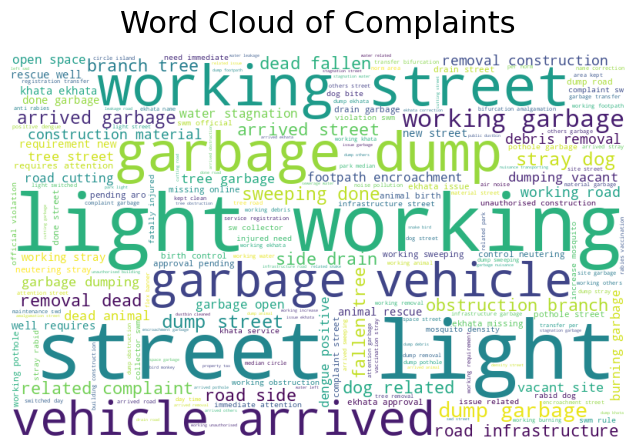

In [9]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['clean_text'])
wc = WordCloud(width=800, height=500, background_color="white").generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.title("Word Cloud of Complaints", fontsize=22, pad=15)
plt.axis('off')
plt.show()

# **Extracting N-grams frequency**

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

# bigrams
vectorizer = CountVectorizer(ngram_range=(2,2))
X = vectorizer.fit_transform(df['clean_text'])

sum_words = X.sum(axis=0)

words_freq = []
for word, idx in vectorizer.vocabulary_.items():
    count = int(sum_words[0, idx])
    words_freq.append((word, count))

words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

words_freq[:20]

[('street light', 41570),
 ('light working', 40109),
 ('garbage dump', 16137),
 ('garbage vehicle', 12135),
 ('vehicle arrived', 12135),
 ('stray dog', 4115),
 ('sweeping done', 3641),
 ('road side', 3269),
 ('side drain', 3269),
 ('obstruction branch', 3161),
 ('branch tree', 3161),
 ('related complaint', 3022),
 ('removal dead', 2884),
 ('dead fallen', 2884),
 ('fallen tree', 2884),
 ('dog related', 2775),
 ('road infrastructure', 2662),
 ('debris removal', 1900),
 ('removal construction', 1900),
 ('construction material', 1900)]

# **Saving cleaned data**

In [11]:
df.to_csv("cleaned_data.csv", index=False)

# **Week 1 Done**

# **Week 2**

In [12]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Project 1/cleaned_data.csv")

df.head(100)

,Text,Department,clean_text
0,Street Light Not Working,Electrical,street light working
1,Street Light Not Working,Electrical,street light working
2,Garbage dump,Solid Waste (Garbage) Related,garbage dump
3,Street Light Not Working,Electrical,street light working
4,Garbage dump,Solid Waste (Garbage) Related,garbage dump
...,...,...,...
95,Garbage dump,Solid Waste (Garbage) Related,garbage dump
96,Road cutting,Road Maintenance(Engg),road cutting
97,water stagnation,Road Maintenance(Engg),water stagnation
98,Requirement For New Street Lights,Electrical,requirement new street light


In [13]:
df.columns

Index(['Text', 'Department', 'clean_text'], dtype='object')

## **Applying TF-IDF Vectorization**

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['clean_text']
y = df['Department']

vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(X)

## **Training logistic regression model**

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=1)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## **Finding accuracy and classification report**

In [16]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9975979523528253


In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                               precision    recall  f1-score   support

                Advertisement       1.00      1.00      1.00       144
         BBMP Election Branch       0.00      0.00      0.00         1
               CORONA COVID19       0.00      0.00      0.00         3
                  Call Center       1.00      0.54      0.70        13
     E khata / Khata services       1.00      1.00      1.00       845
                    Education       0.00      0.00      0.00         2
                   Electrical       1.00      1.00      1.00      8407
                       Estate       0.00      0.00      0.00        16
                       Forest       1.00      1.00      1.00      1245
                  Health Dept       1.00      1.00      1.00       690
               Indira Canteen       1.00      0.76      0.86        33
       Information Technology       1.00      1.00      1.00         8
                        Lakes       1.00      1.00      1.00        74
     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [18]:
df[['Text', 'Department']].drop_duplicates().shape

(185, 2)

The dataset contains only 185 unique complaint types repeated across 120k entries. As most of the people complain about the same things which lacks uniqueness (i.e. street light not working, potholes etc.). Each complaint type strongly corresponds to a single department label, making the classification task relatively straightforward. This explains the very high model accuracy.

# **Week 2 Done**

# **Week 3**

In [19]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Project 1/cleaned_data.csv")

## **Using Vader compound scoring for sentiment score**

In [20]:
!pip install vaderSentiment

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.3 MB/s eta 0:00:00


In [21]:
analyzer = SentimentIntensityAnalyzer()

df['sentiment_score'] = df['Text'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)

print(df[['Text', 'sentiment_score']].head(10))

                       Text  sentiment_score
0  Street Light Not Working           0.0000
1  Street Light Not Working           0.0000
2              Garbage dump          -0.3818
3  Street Light Not Working           0.0000
4              Garbage dump          -0.3818
5  Street Light Not Working           0.0000
6  Street Light Not Working           0.0000
7  Street Light Not Working           0.0000
8              Garbage dump          -0.3818
9     footpath encroachment           0.0000


In [22]:
def score_to_priority(score):
    if score <= -0.5:
        return "Critical"
    elif score <= -0.1:
        return "High"
    elif score <= 0.2:
        return "Medium"
    else:
        return "Low"

df['priority'] = df['sentiment_score'].apply(score_to_priority)

print(df['priority'].value_counts())

priority
Medium      95088
High        24571
Low          4233
Critical     3082
Name: count, dtype: int64


## **Visualizing sentiment score distribution and priority count**

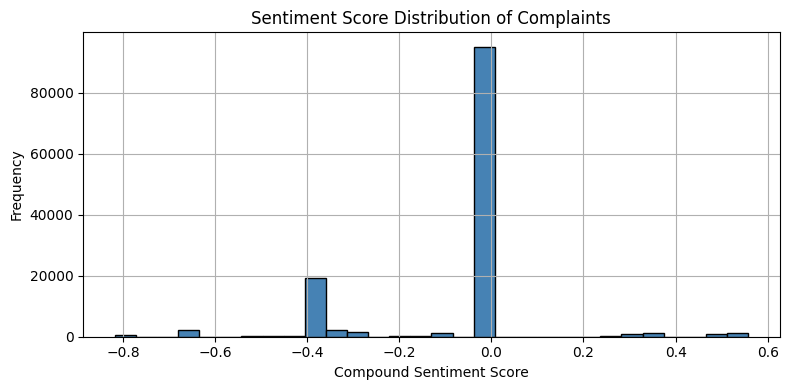

In [23]:
plt.figure(figsize=(8, 4))
df['sentiment_score'].hist(bins=30, color='steelblue', edgecolor='black')
plt.title('Sentiment Score Distribution of Complaints')
plt.xlabel('Compound Sentiment Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('sentiment_distribution.png')
plt.show()

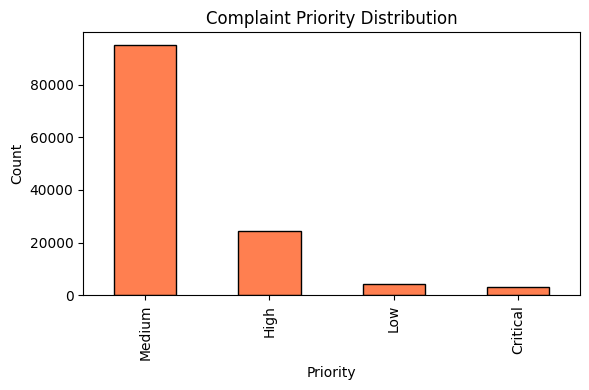

In [24]:
plt.figure(figsize=(6, 4))
df['priority'].value_counts().plot(kind='bar', color='coral', edgecolor='black')
plt.title('Complaint Priority Distribution')
plt.xlabel('Priority')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('priority_distribution.png')
plt.show()

## **TF-IDF + Logistic Regression model with classification report**

In [25]:
vectorizer_priority = TfidfVectorizer()
X = vectorizer_priority.fit_transform(df['clean_text'])
y = df['priority']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

priority_model = LogisticRegression(max_iter=1000)
priority_model.fit(X_train, y_train)

y_pred = priority_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9996062216971845

Classification Report:
              precision    recall  f1-score   support

    Critical       1.00      0.99      0.99       626
        High       1.00      1.00      1.00      4959
         Low       1.00      1.00      1.00       863
      Medium       1.00      1.00      1.00     18947

    accuracy                           1.00     25395
   macro avg       1.00      1.00      1.00     25395
weighted avg       1.00      1.00      1.00     25395



The high accuracy is a known limitation of this dataset. The BBMP dataset
contains only 179 unique complaint types, and priority labels were generated using a rule-based system. As a result, the model learns to replicate these
rules rather than generalizing from true sentiment patterns.

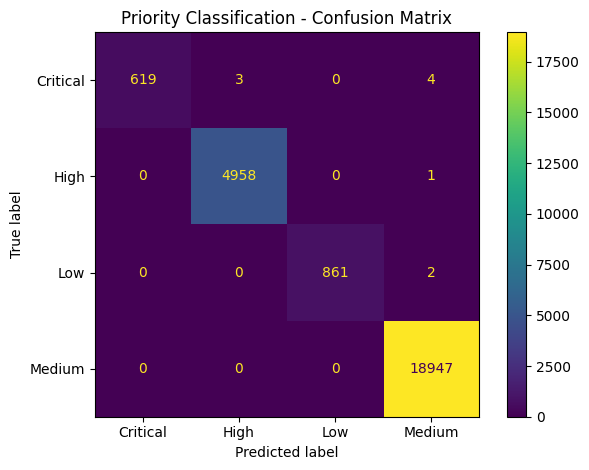

In [26]:
ConfusionMatrixDisplay.from_estimator(priority_model, X_test, y_test)
plt.title("Priority Classification - Confusion Matrix")
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

In [29]:
def predict_complaint(text):
    # Clean the text
    clean = clean_text(text)  # your function from Week 1

    # Predict department (from Week 2 model)
    dept_input = vectorizer.transform([clean])
    department = model.predict(dept_input)[0]

    # Predict priority using VADER + classifier
    score = analyzer.polarity_scores(text)['compound']
    priority_input = vectorizer_priority.transform([clean])
    priority = priority_model.predict(priority_input)[0]

    return {
        "complaint": text,
        "department": department,
        "sentiment_score": round(score, 3),
        "priority": priority
    }

# Test it
result = predict_complaint("There is a water leak on the main road")
print(result)

{'complaint': 'There is a water leak on the main road', 'department': 'Road Maintenance(Engg)', 'sentiment_score': -0.34, 'priority': 'Medium'}


# **Week 3 Done**